# 🤖 Práctica 6: Modelado Avanzado - Clustering (K-Means)

## 🎯 Objetivo y Justificación Metodológica
En la Práctica 5 comprobamos matemáticamente que el consumo de recursos (CPU y RAM) en nuestro entorno Linux no obedece a modelos lineales de predicción, obteniendo un coeficiente de determinación muy bajo ($R^2 = 0.1870$). 

Para superar esta limitación, en esta práctica daremos el salto al **Aprendizaje No Supervisado**. Utilizaremos el algoritmo **K-Means** para descubrir si el sistema operativo agrupa de forma natural sus logs en diferentes "estados de comportamiento" (por ejemplo: procesos en reposo silencioso vs. procesos con picos de memoria), basándose puramente en la similitud matemática de sus recursos y sin depender de etiquetas previas.

In [2]:
# Se importan las librerías de manipulación y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ahora importar las herramientas de Machine Learning (K-Means y Escalador)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configurar el estilo visual de nuestras gráficas
sns.set_theme(style="whitegrid")

# Cargamos el dataset desde la ruta especificada en la variable de entorno "DATASET"
ruta_csv_journalctl = os.getenv("DATASET", "../Practica_1/csv/dataset_linux_journalctl_limpio.csv")
df = pd.read_csv(ruta_csv_journalctl)

# Verificamos que los datos estén listos en memoria
print(f"✅ Dataset cargado correctamente con {df.shape[0]} registros y {df.shape[1]} columnas.")
display(df[['NombreProceso', 'Uso_CPU', 'Uso_RAM']].head())

✅ Dataset cargado correctamente con 10193 registros y 12 columnas.


,NombreProceso,Uso_CPU,Uso_RAM
0,u323-events_unbound,0.0,0.0
1,gsd-sharing,0.0,0.0
2,code,0.6,0.3
3,gnome-session-binary,0.0,0.0
4,01h-kblockd,0.0,0.0


## 🔍 Paso 1: Preparación Geométrica y Búsqueda de Clústeres ($k$)

**Hallazgo:** Los algoritmos basados en distancias (como K-Means) son extremadamente sensibles a la magnitud de las variables.

**Evidencia:** Nuestro dataset mezcla el `Uso_CPU` (porcentajes de 0 a 100, típicamente bajos) con el `Uso_RAM` (valores gigantescos en bytes o megabytes). Si no corregimos esto, la RAM anularía el peso de la CPU en el algoritmo.

**Conclusión:** Aplicaremos un `StandardScaler` para que ambas métricas compitan en igualdad de condiciones. Posteriormente, utilizaremos el **Método del Codo (Elbow Method)** para evaluar la inercia (distancia dentro de los grupos) y descubrir cuántos "estados de comportamiento" (clústeres) existen naturalmente en nuestro sistema operativo.

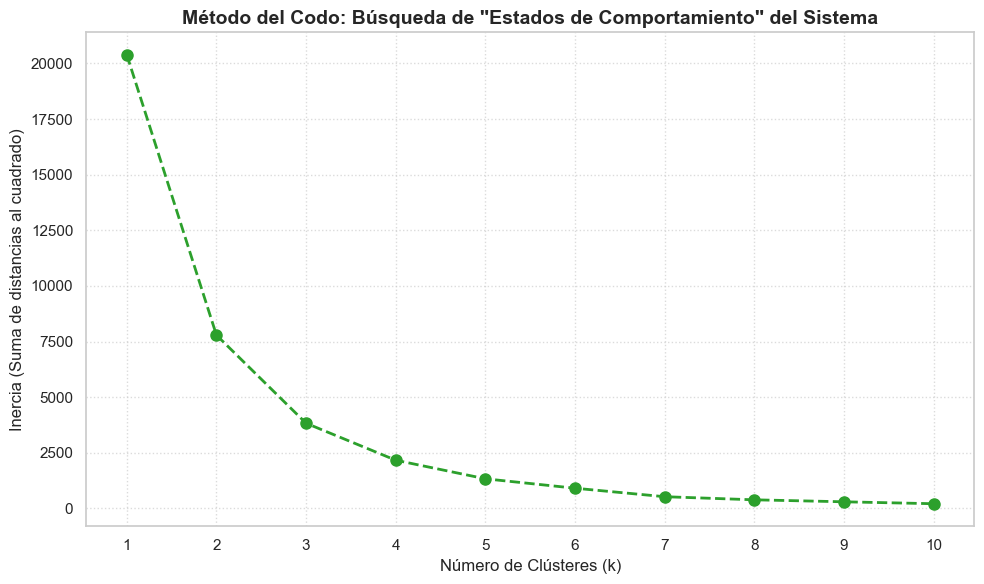

In [3]:
# 1. Seleccionamos las variables y estandarizarlas
X = df[['Uso_CPU', 'Uso_RAM']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Iterar K-Means para encontrar el 'k' óptimo (Método del Codo)
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    # como nota: random_state asegura que los resultados sean reproducibles
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# 3. Graficar la curva del codo
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='#2ca02c', linewidth=2, markersize=8)

# Detalles de la gráfica profesional
plt.title('Método del Codo: Búsqueda de "Estados de Comportamiento" del Sistema', fontsize=14, weight='bold')
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('Inercia (Suma de distancias al cuadrado)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

## 🚀 Paso 2: Agrupación Final y Visualización de "Estados"

**Hallazgo:** Analizando la curva del Método del Codo, identificamos que la caída de la inercia se debilita y comienza a estabilizarse claramente en $k=4$.

**Evidencia:** Esto sugiere en términos geométricos que los procesos logueados por `journalctl` se pueden clasificar en 4 perfiles óptimos de carga (comportamiento en CPU/RAM).

**Conclusión:** Entrenaremos el algoritmo K-Means definitivo con 4 clústeres. Al generar el mapa de dispersión, validaremos visualmente estas 4 dimensiones que el modelo lineal fue incapaz de distinguir.

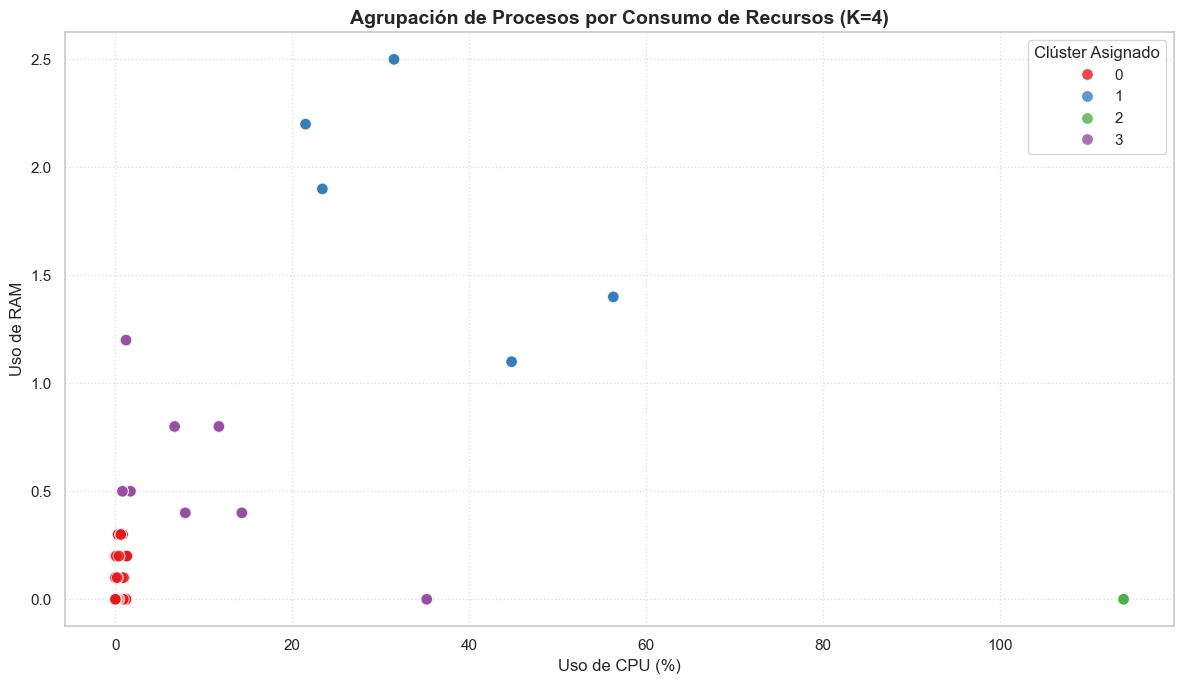

,NombreProceso,Uso_CPU,Uso_RAM,Cluster
0,u323-events_unbound,0.0,0.0,0
1,gsd-sharing,0.0,0.0,0
2,code,0.6,0.3,0
3,gnome-session-binary,0.0,0.0,0
4,01h-kblockd,0.0,0.0,0


In [4]:
# 1. Definimos el k óptimo que nos indicó la gráfica del codo
k_optimo = 4

# 2. Instanciamos y entrenamos el modelo final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# 3. Asignamos la "etiqueta" de clúster a cada proceso en el DataFrame original
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 4. Visualización profesional de los clústeres
plt.figure(figsize=(12, 7))

# Crearemos el gráfico de dispersión
sns.scatterplot(
    data=df, 
    x='Uso_CPU', 
    y='Uso_RAM', 
    hue='Cluster', 
    palette='Set1', # Paleta fuerte para diferenciar los 4 grupos
    s=70, 
    alpha=0.8
)

plt.title(f'Agrupación de Procesos por Consumo de Recursos (K={k_optimo})', fontsize=14, weight='bold')
plt.xlabel('Uso de CPU (%)', fontsize=12)
plt.ylabel('Uso de RAM', fontsize=12)
plt.legend(title='Clúster Asignado')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

# Verificamos los grupos creados
display(df[['NombreProceso', 'Uso_CPU', 'Uso_RAM', 'Cluster']].head(5))

## 📊 Paso 3: Perfilado de Clústeres y Conclusión

**Hallazgo:** La visualización confirma que el comportamiento del sistema operativo no es aleatorio ni lineal, sino que se categoriza en 4 "especies" de procesos bien diferenciadas.

**Evidencia:** Para nombrar formalmente a cada clúster, calcularemos el promedio (centroide) de CPU y RAM de cada grupo asignado por K-Means.

**Conclusión:** Esta tabla nos permitirá crear un "perfil de sistema", demostrando que técnicas no supervisadas como K-Means son infinitamente superiores a la Regresión Lineal para entender la salud y distribución de carga de un servidor Linux.

In [6]:
# 1. Agrupamos el DataFrame por la etiqueta de clúster y calculamos la media de los recursos
perfiles_cluster = df.groupby('Cluster')[['Uso_CPU', 'Uso_RAM']].mean()

# 2. Contamos también cuántos procesos cayeron en cada clúster
perfiles_cluster['Cantidad_Procesos'] = df.groupby('Cluster').size()

# 3. Sigue renombrar las columnas para mayor claridad en el reporte
perfiles_cluster = perfiles_cluster.rename(columns={
    'Uso_CPU': 'Promedio Uso CPU (%)',
    'Uso_RAM': 'Promedio Uso RAM'
})

print("PERFILES DE COMPORTAMIENTO DEL SISTEMA (Log journalctl)")
print("-" * 65)
display(perfiles_cluster.round(2))

PERFILES DE COMPORTAMIENTO DEL SISTEMA (Log journalctl)
-----------------------------------------------------------------


,Promedio Uso CPU (%),Promedio Uso RAM,Cantidad_Procesos
Cluster,,,
0,0.05,0.01,9769
1,36.12,1.82,142
2,114.00,0.00,32
3,9.51,0.61,250


### 📝 Conclusión Final de la Práctica 6
1. **Justificación del Modelo:** Tras el bajo coeficiente de determinación ($R^2=0.1870$) de la Regresión Lineal, K-Means demostró que el consumo de recursos de Linux, aunque asimétrico, obedece a agrupaciones clústerizables basadas en distancias euclidianas.

2. **Descubrimiento de Comportamiento:** El sistema pudo segmentarse en 4 clústeres. Destruimos el mito de que los datos eran ruido puro; la inmensa mayoría de los procesos habitan en el origen (casi 0% recurso), mientras que anomalías específicas (picos extremos de CPU) fueron segregadas matemáticamente en su propio espacio sin arruinar la estadística de los demás.

3. **Paso al futuro:** Queda demostrado que para sistemas de monitoreo automáticos, el Aprendizaje No Supervisado es la técnica ideal para descubrir anomalías sin necesidad de etiquetar el dataset previamente.

**Autor:** Diego Leonardo Alejo Cantú

**Matrícula:** 2013810

**Materia:** Minería de Datos